# Baseline Model Training and Evaluation

This notebook trains and evaluates baseline ML models using extracted acoustic + multifractal features.

## What it does
- Loads feature tables from `src.features`
- Builds a model-ready dataset
- Trains multiple baseline classifiers
- Compares performance (accuracy, balanced accuracy, macro-F1)
- Visualizes confusion matrices

> Note: current splits are random sample-level. For clinically safer evaluation, consider speaker-grouped splits in a follow-up.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sys.path.append("..")
from src.features import FeatureOptions, load_feature_tables

g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Keep this small for quick iteration; set to None for full training set
MAX_SAMPLES_PER_CLASS = 200

opts = FeatureOptions(
    prefix=Path(".."),
    include_splits=True,
    random_seed=RANDOM_SEED,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
)

opts

FeatureOptions(prefix=WindowsPath('..'), input_manifest=WindowsPath('data/processed/manifests/dataset_manifest.csv'), output_core=WindowsPath('data/processed/features/sample_core.csv'), output_acoustic=WindowsPath('data/processed/features/acoustic_features.csv'), output_multifractal=WindowsPath('data/processed/features/multifractal_features.csv'), output_opensmile=WindowsPath('data/processed/features/opensmile_features.csv'), output_splits=WindowsPath('data/processed/features/sample_splits.csv'), output_summary_json=WindowsPath('data/processed/features/feature_summary.json'), include_splits=True, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_seed=42, max_samples_per_class=200, normalize_audio=True, target_sample_rate=None, mfdfa_order=1, mfdfa_q_min=-5.0, mfdfa_q_max=5.0, mfdfa_q_step=1.0, mfdfa_num_scales=20)

In [3]:
tables = load_feature_tables(options=opts, build_if_missing=True, save_if_built=True)

for name, df in tables.items():
    print(f"{name}: {df.shape}")

core_df = tables["core"].copy()
acoustic_df = tables["acoustic"].copy()
multifractal_df = tables["multifractal"].copy()
opensmile_df = tables.get("opensmile", pd.DataFrame()).copy()
splits_df = tables.get("splits", pd.DataFrame())

Extracting features:  18%|█▊        | 216/1214 [02:14<07:53,  2.11sample/s]g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\MFDFA\MFDFA.py:249: RuntimeWarning: divide by zero encountered in float_power
  np.mean(np.float_power(F, q / 2), axis=1),
Extracting features:  21%|██▏       | 261/1214 [02:48<04:48,  3.31sample/s]g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\MFDFA\MFDFA.py:249: RuntimeWarning: divide by zero encountered in float_power
  np.mean(np.float_power(F, q / 2), axis=1),
Extracting features: 100%|██████████| 1214/1214 [10:59<00:00,  1.84sample/s]


core: (1214, 18)
acoustic: (1214, 87)
multifractal: (1214, 17)
opensmile: (1214, 91)
splits: (1214, 3)


In [4]:
# Build one training table
df = core_df.merge(acoustic_df, on="sample_key", how="left")
df = df.merge(multifractal_df, on="sample_key", how="left")
if not opensmile_df.empty:
    df = df.merge(opensmile_df, on="sample_key", how="left")
if not splits_df.empty:
    df = df.merge(splits_df, on="sample_key", how="left")

# Filter to successfully extracted samples
if "feature_status" in df.columns:
    df = df[df["feature_status"].isin(["ok", "partial_failure"])].copy()
if "acoustic_status" in df.columns:
    df = df[df["acoustic_status"] == "ok"].copy()
if "mf_status" in df.columns:
    df = df[df["mf_status"] == "ok"].copy()
if "opensmile_status" in df.columns:
    df = df[df["opensmile_status"] == "ok"].copy()

df.shape

(1214, 212)

In [5]:
# Select target and features
target_col = "pathology_de" if "pathology_de" in df.columns else "pathology_en"

exclude_cols = {
    "sample_key",
    "duplicate_class_key",
    "recording_id",
    "speaker_id",
    "wav_path",
    "feature_status",
    "feature_error",
    "acoustic_status",
    "acoustic_error",
    "mf_status",
    "mf_error",
    "opensmile_status",
    "opensmile_error",
    "split",
    "split_seed",
    "pathology_de",
    "pathology_en",
}

numeric_feature_cols = [
    c for c in df.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])
]

X = df[numeric_feature_cols].copy()
y_binary = df["is_healthy"].astype(int).copy() # 1 for healthy, 0 for pathological
y_multi = df[target_col].astype(str).copy()

print(f"Samples: {len(df)}")
print(f"Binary Classes: {y_binary.nunique()}")
print(f"Multi Classes: {y_multi.nunique()}")
print(f"Numeric features: {len(numeric_feature_cols)}")

Samples: 1214
Binary Classes: 2
Multi Classes: 7
Numeric features: 192


In [6]:
# Train/test split: prefer precomputed split table when available
if "split" in df.columns and df["split"].notna().any():
    train_mask = df["split"] == "train"
    val_mask = df["split"] == "val"
    test_mask = df["split"] == "test"

    X_train = X[train_mask | val_mask]
    y_bin_train = y_binary[train_mask | val_mask]
    y_multi_train = y_multi[train_mask | val_mask]
    
    X_test = X[test_mask]
    y_bin_test = y_binary[test_mask]
    y_multi_test = y_multi[test_mask]

    if len(X_test) == 0:
        X_train, X_test, y_bin_train, y_bin_test, y_multi_train, y_multi_test = train_test_split(
            X, y_binary, y_multi, test_size=0.2, stratify=y_multi, random_state=RANDOM_SEED
        )
else:
    X_train, X_test, y_bin_train, y_bin_test, y_multi_train, y_multi_test = train_test_split(
        X, y_binary, y_multi, test_size=0.2, stratify=y_multi, random_state=RANDOM_SEED
    )

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1052, 192)
Test shape: (162, 192)


In [7]:
# Shared preprocessing for numeric feature space
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[("num", numeric_transformer, numeric_feature_cols)],
    remainder="drop",
)

In [8]:
models = {
    "LogReg": LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_SEED),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_SEED,
        class_weight="balanced_subsample",
        n_jobs=-1,
    ),
    "SVM-RBF": SVC(kernel="rbf", C=3.0, gamma="scale", class_weight="balanced"),
    "XGBoost": XGBClassifier(random_state=RANDOM_SEED, n_jobs=-1, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=RANDOM_SEED, n_jobs=-1, class_weight="balanced", verbose=-1),
}

results_bin = []
trained_pipelines_bin = {}

print("--- Binary Classification (Healthy vs Pathological) ---")
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", model),
    ])

    pipe.fit(X_train, y_bin_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_bin_test, y_pred)
    bacc = balanced_accuracy_score(y_bin_test, y_pred)
    f1m = f1_score(y_bin_test, y_pred, average="macro", zero_division=0)

    results_bin.append({
        "model": name,
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "f1_macro": f1m,
    })

    trained_pipelines_bin[name] = (pipe, y_pred)

results_bin_df = pd.DataFrame(results_bin).sort_values(by="f1_macro", ascending=False)
display(results_bin_df)

--- Binary Classification (Healthy vs Pathological) ---


g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,balanced_accuracy,f1_macro
0,LogReg,1.000000,1.000,1.000000
4,LightGBM,1.000000,1.000,1.000000
3,XGBoost,1.000000,1.000,1.000000
2,SVM-RBF,0.987654,0.975,0.983114
1,RandomForest,0.876543,0.750,0.795455


In [9]:
# Multi-class classification on pathological samples only
pathological_train_mask = y_bin_train == 0
pathological_test_mask = y_bin_test == 0

X_train_patho = X_train[pathological_train_mask]
y_multi_train_patho = y_multi_train[pathological_train_mask]

X_test_patho = X_test[pathological_test_mask]
y_multi_test_patho = y_multi_test[pathological_test_mask]

# Encode labels for XGBoost/LightGBM
le = LabelEncoder()
y_multi_train_patho_enc = le.fit_transform(y_multi_train_patho)
y_multi_test_patho_enc = le.transform(y_multi_test_patho)

results_multi = []
trained_pipelines_multi = {}

print("--- Multi-class Classification (Specific Pathology) ---")
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", model),
    ])

    pipe.fit(X_train_patho, y_multi_train_patho_enc)
    y_pred_enc = pipe.predict(X_test_patho)
    y_pred = le.inverse_transform(y_pred_enc)

    acc = accuracy_score(y_multi_test_patho, y_pred)
    bacc = balanced_accuracy_score(y_multi_test_patho, y_pred)
    f1m = f1_score(y_multi_test_patho, y_pred, average="macro", zero_division=0)

    results_multi.append({
        "model": name,
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "f1_macro": f1m,
    })

    trained_pipelines_multi[name] = (pipe, y_pred)

results_multi_df = pd.DataFrame(results_multi).sort_values(by="f1_macro", ascending=False)
display(results_multi_df)

--- Multi-class Classification (Specific Pathology) ---


g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,balanced_accuracy,f1_macro
2,SVM-RBF,0.344262,0.370433,0.302002
4,LightGBM,0.336066,0.309913,0.291589
3,XGBoost,0.303279,0.287944,0.269205
1,RandomForest,0.270492,0.269762,0.250812
0,LogReg,0.303279,0.310087,0.229082


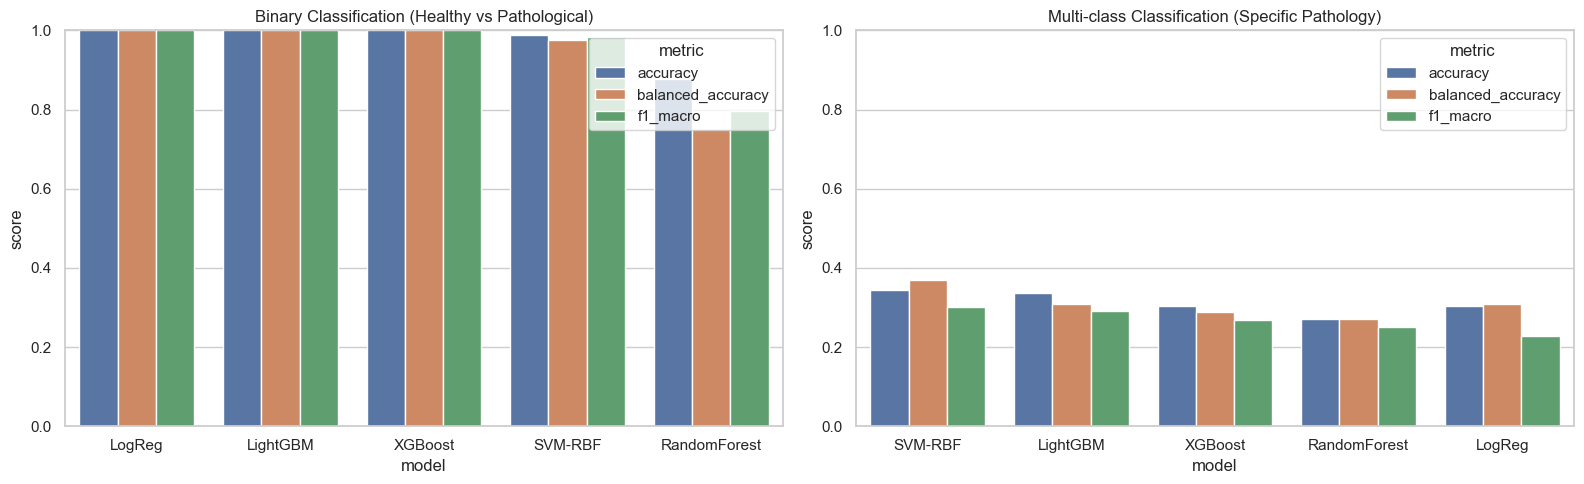

In [10]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_df_bin = results_bin_df.melt(id_vars="model", var_name="metric", value_name="score")
sns.barplot(data=plot_df_bin, x="model", y="score", hue="metric", ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title("Binary Classification (Healthy vs Pathological)")

plot_df_multi = results_multi_df.melt(id_vars="model", var_name="metric", value_name="score")
sns.barplot(data=plot_df_multi, x="model", y="score", hue="metric", ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title("Multi-class Classification (Specific Pathology)")

plt.tight_layout()
plt.show()

In [11]:
best_model_name_bin = results_bin_df.iloc[0]["model"]
best_pipe_bin, best_pred_bin = trained_pipelines_bin[best_model_name_bin]

print(f"Best Binary Model: {best_model_name_bin}")
print(classification_report(y_bin_test, best_pred_bin, zero_division=0))

best_model_name_multi = results_multi_df.iloc[0]["model"]
best_pipe_multi, best_pred_multi = trained_pipelines_multi[best_model_name_multi]

print(f"\nBest Multi-class Model: {best_model_name_multi}")
print(classification_report(y_multi_test_patho, best_pred_multi, zero_division=0))

Best Binary Model: LogReg
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       122
           1       1.00      1.00      1.00        40

    accuracy                           1.00       162
   macro avg       1.00      1.00      1.00       162
weighted avg       1.00      1.00      1.00       162


Best Multi-class Model: SVM-RBF
                        precision    recall  f1-score   support

   Phonationsknötchen       0.20      0.08      0.12        24
          Reinke Ödem       0.50      0.45      0.48        44
       Rekurrensparese       0.32      0.29      0.30        28
Spasmodische Dysphonie       0.13      0.60      0.21         5
      Stimmlippenpolyp       0.38      0.43      0.40        21

              accuracy                           0.34       122
             macro avg       0.31      0.37      0.30       122
          weighted avg       0.36      0.34      0.34       122



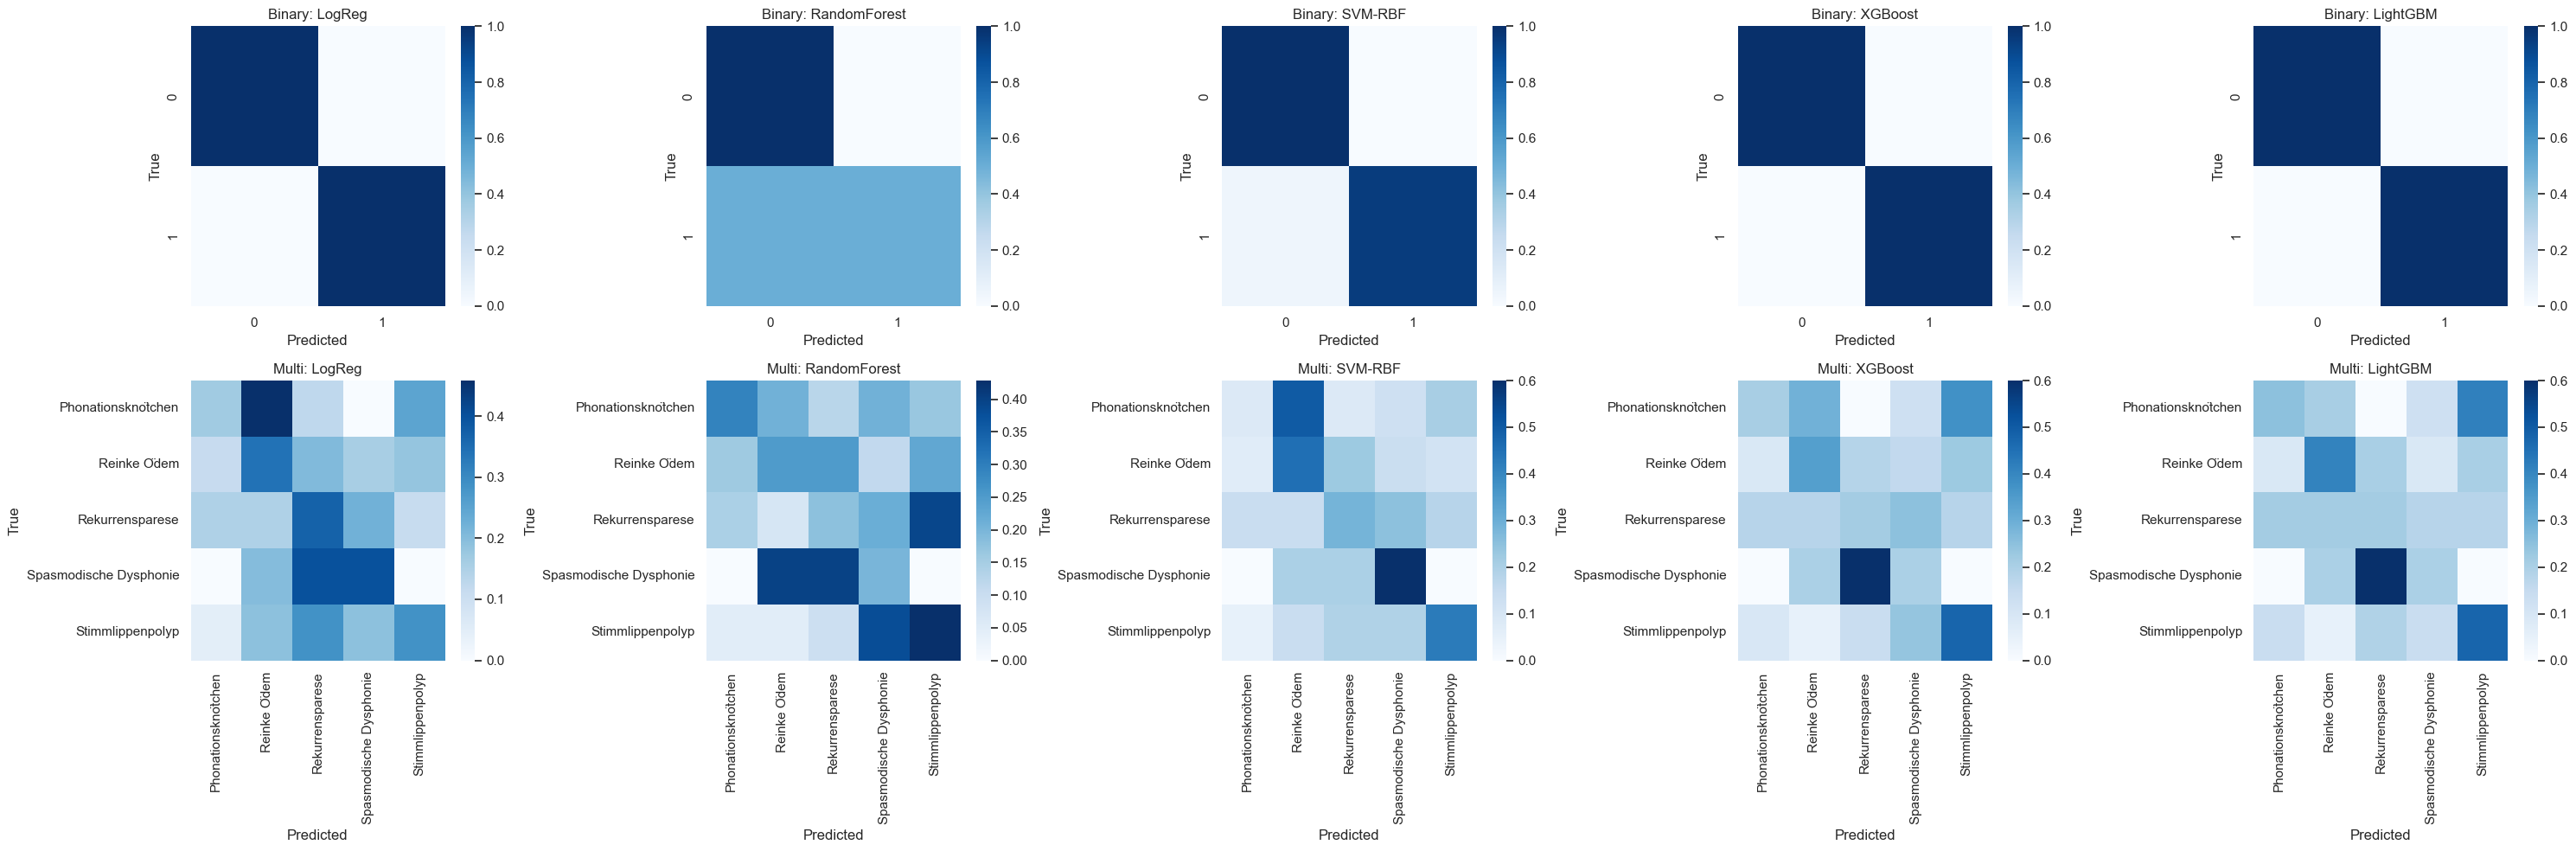

In [12]:
labels_bin = sorted(y_bin_test.unique())
labels_multi = sorted(y_multi_test_patho.unique())

n_models = len(trained_pipelines_bin)
fig, axes = plt.subplots(2, n_models, figsize=(6 * n_models, 10), squeeze=False)

for i, (name, (_, pred)) in enumerate(trained_pipelines_bin.items()):
    cm = confusion_matrix(y_bin_test, pred, labels=labels_bin)
    cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

    sns.heatmap(
        cm_norm,
        annot=False,
        cmap="Blues",
        xticklabels=labels_bin,
        yticklabels=labels_bin,
        ax=axes[0, i],
    )
    axes[0, i].set_title(f"Binary: {name}")
    axes[0, i].set_xlabel("Predicted")
    axes[0, i].set_ylabel("True")

for i, (name, (_, pred)) in enumerate(trained_pipelines_multi.items()):
    cm = confusion_matrix(y_multi_test_patho, pred, labels=labels_multi)
    cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

    sns.heatmap(
        cm_norm,
        annot=False,
        cmap="Blues",
        xticklabels=labels_multi,
        yticklabels=labels_multi,
        ax=axes[1, i],
    )
    axes[1, i].set_title(f"Multi: {name}")
    axes[1, i].set_xlabel("Predicted")
    axes[1, i].set_ylabel("True")

plt.tight_layout()
plt.show()

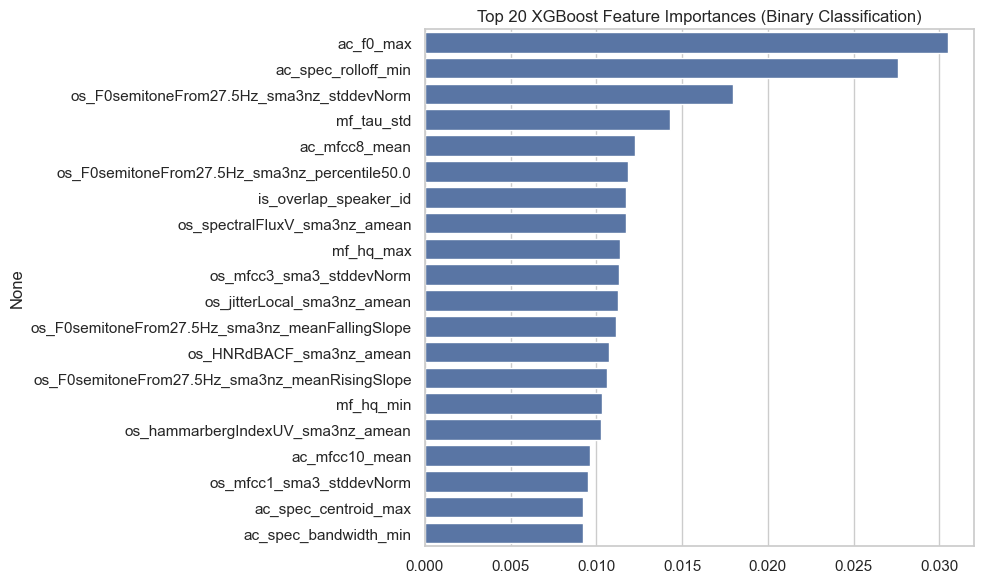

,importance
ac_f0_max,0.030489
ac_spec_rolloff_min,0.027602
os_F0semitoneFrom27.5Hz_sma3nz_stddevNorm,0.017952
mf_tau_std,0.014269
ac_mfcc8_mean,0.012226
os_F0semitoneFrom27.5Hz_sma3nz_percentile50.0,0.011852
is_overlap_speaker_id,0.011752
os_spectralFluxV_sma3nz_amean,0.011744
mf_hq_max,0.011381
os_mfcc3_sma3_stddevNorm,0.011304


In [14]:
# Optional: inspect top feature importances for the best binary model (e.g., XGBoost)
if "XGBoost" in trained_pipelines_bin:
    xgb_pipe, _ = trained_pipelines_bin["XGBoost"]
    xgb_model = xgb_pipe.named_steps["model"]

    importances = pd.Series(xgb_model.feature_importances_, index=numeric_feature_cols)
    top_imp = importances.sort_values(ascending=False).head(20)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_imp.values, y=top_imp.index)
    plt.title("Top 20 XGBoost Feature Importances (Binary Classification)")
    plt.tight_layout()
    plt.show()

    display(top_imp.to_frame("importance"))

In [15]:
# Hyperparameter Tuning for the best binary model (e.g., XGBoost)
print("--- Hyperparameter Tuning (Binary Classification) ---")

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.2],
}

# Assuming XGBoost is one of the best, let's tune it
xgb_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", XGBClassifier(random_state=RANDOM_SEED, n_jobs=-1, eval_metric="logloss")),
])

grid_search = GridSearchCV(
    xgb_pipe, param_grid, cv=3, scoring="f1_macro", n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_bin_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV F1 Macro: {grid_search.best_score_:.4f}")

best_tuned_model = grid_search.best_estimator_
y_pred_tuned = best_tuned_model.predict(X_test)

print("\nTuned Model Test Performance:")
print(classification_report(y_bin_test, y_pred_tuned, zero_division=0))

--- Hyperparameter Tuning (Binary Classification) ---
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100}
Best CV F1 Macro: 1.0000

Tuned Model Test Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       122
           1       1.00      1.00      1.00        40

    accuracy                           1.00       162
   macro avg       1.00      1.00      1.00       162
weighted avg       1.00      1.00      1.00       162



## Next recommendations

- Add speaker-grouped splits for leakage-safe evaluation.
- Run hyperparameter search on the best baseline.
- Compare acoustic-only vs multifractal-only vs fused feature sets.